In [1]:
#Učitavanje biblioteka
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, poisson, cauchy, iqr, uniform
from scipy.stats import kstwo, kstest, ks_2samp
from scipy.stats import mannwhitneyu, ranksums, wilcoxon, anderson, shapiro, ttest_ind, ttest_1samp, f
from urllib.request import urlopen
import matplotlib
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

In [2]:
#Učitavanje podataka
ks_uzorci = np.genfromtxt('gr.dat', skip_header=2, skip_footer=2)
mJy, G, R = ks_uzorci.T

### Rekonstrukcija sirovih podataka

Ovo je neophodno zato što su podaci u gr.dat fajlu dati kao histogrami, odnosno kao broj pojavljivanja neke vrednosti fluksa unutar određenog opsega. Kolona $G$ predstavlja fluks snimljen ugalaksijama a $R$ nasumične tačke na nebu.

Kako bismo uradili K-S i U test nama trebaju pravi podaci, tako da treba da rekonstruišemo sirove podatke, podatke koji su postojali pre grupisanja u binove.

In [3]:
# np.repeat uzima vrednost fluksa (mJy) i ponavlja je onoliko puta kolika je frekvencija
sirovi_G = np.repeat(mJy, G.astype(int)) #funkcija .astype(int) pretvara G i R u cele brojeve
sirovi_R = np.repeat(mJy, R.astype(int))

print(len(sirovi_G))
print(len(sirovi_R))

386
290


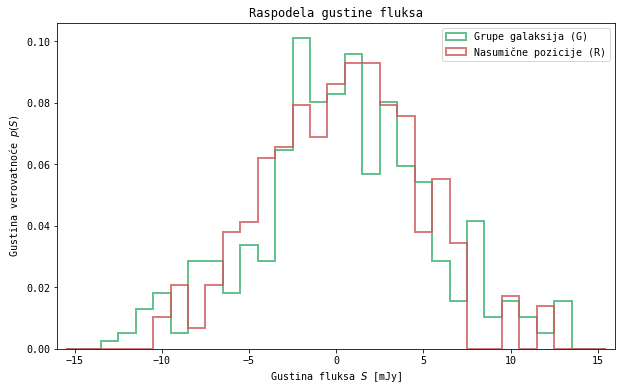

In [4]:
#Plotovanje
plt.figure(figsize=(10, 6))

# Koristim density=True da bih uporedila oblike raspodela bez obzira na različit broj merenja (386 i 290)
# Pošto podaci idu od -15 do 15, granice sam stavila od -15.5 do 15.5 sa korakom 1 (jer je onda centrirano na 0.5)
bins = np.arange(-15.5, 16.5, 1.0)
plt.hist(sirovi_G, bins=bins, histtype='step', lw=2, color='mediumseagreen', alpha=0.8, density=True, label='Grupe galaksija (G)')
plt.hist(sirovi_R, bins=bins, histtype='step', lw=2,color='indianred', alpha=0.8, density=True, label='Nasumične pozicije (R)')
plt.xlabel('Gustina fluksa $S$ [mJy]')
plt.ylabel('Gustina verovatnoće $p(S)$')
plt.title('Raspodela gustine fluksa')
plt.xlim(-16, 16)
plt.legend()
plt.show()

In [5]:
print(f'Grupe galaksija vs. Nasumične pozicije: {ks_2samp(sirovi_G, sirovi_R)}')
print(mannwhitneyu(sirovi_G, sirovi_R))

Grupe galaksija vs. Nasumične pozicije: KstestResult(statistic=0.06741111309630159, pvalue=0.4159511900220732, statistic_location=7.0, statistic_sign=-1)
MannwhitneyuResult(statistic=56613.5, pvalue=0.7976086236669382)


---
Ako je nulta hipoteza $H_0$ da su ove dve raspodele iste, odnosno da ne postoji eksces, ispitujemo je na sledeć način:

-  Kolmogorov-Smirnov dvouzorački test:
    - Na osnovu **statistic = 0.06741111309630159** možemo da zaključimo da je maksimalno vertikalno rastojanje između gustine fluksa kada su posmatrane grupe galaksija i nasumične pozicije malo i iznosi 6.7%
    - Na osnovu **p - vrednosti = 0.41595119002207** odnosno 41.6% vidimo da ona premašuje standardnu granicu za odbacivanje nulte hipoteze ($\alpha = 0.05$, tj. 5%), što znači da ne možemo da odbacimo nultu hipotezu

- U-test:
    - **statistic=56613.5**. Maksimalna moguća vrednost za U statistiku je $n_1 \times n_2$ što u ovom slučaju iznosi (386 $\times$ 290) = 111940, odnosno očekivana vrednost statistike ako su raspodele iste iznosi polovinu ove vrednosti (55970). Iz dobijene vrednosti od 56613.5 zaključujemo da ona odgovara teorijski predviđenoj vrednosti, odnosno da su uzorci balansirani
    - **p vrednost iznosi 0.7976086236669382** tj. 79.8% što je veće od 5%, što znači da ne možemo da odbacimo nultu hipotezu

Na osnovu svega ovoga, može da se zaključi da nije moguće odbaciti nultu hipotezu, odnosno da su raspodele gustine fluksa kada su posmatrani centri galaksija i nasumične tačke na nebu previše slične, odnosno da ne možemo da zaključimo da postoji esces u podacima.

### Drugi deo zadatka

In [6]:
np.random.seed(0)
n = 10 #Broj posmatranja
epsilon = 0.3 #Ovo sam samo nasumično izabrala da vidim da li radi
sample1 = norm.rvs(0,1,n) #Jedna normalna raspodela centrirana u 0, generiše se n vrednosti
sample2 = (1 - epsilon)*norm.rvs(0,1, n) + epsilon*norm.rvs(0,3, n) #Mešavina dve normalne raspodele

print(ttest_ind(sample1, sample2))

Ttest_indResult(statistic=0.5154684361762473, pvalue=0.6124987564130823)


Tumačenje rezultata za jedno epsilon:
- t-statistika (statistic = 0.52): vrednost je blizu nule, što nam govori da su empirijske srednje vrednosti ova dva uzorka veoma blizu jedna drugoj
- p-vrednost (pvalue = 0.6125 odnosno $61.25\%$): Pošto je p-vrednost znatno veća od $5\%$, ne možemo da odbacimo nultu hipotezu
- Zaključak: Test potvrđuje da između grupa sample1 i sample2 nema statistički značajne razlike

### Sad treba za 20 vrednosti $\epsilon$ i $N=1000$

In [7]:
np.random.seed(0)

epsilons = np.linspace(0, 0.5, 20) 

def stopa_odbacivanja(epsilons, mu, n=10, N=1000, alpha=0.05):
    udeo_odbacivanja = [] #Ovde ću da upisujem na kraju udeo slučajeva u kojima se hipoteza odbacuje 
    
    for eps in epsilons: #Za svako epsilon
    
        broj_odbacivanja = 0 #Ovo se svaki put restartuje za različito epsilon, ovo je samo brojač
    
        for i in range(N): #a svako generisanje
    
            sample1 = norm.rvs(0, 1, n) 
            sample2 = (1 - eps)*norm.rvs(mu,1, n) + eps*norm.rvs(0,3, n)

            stat, p = ttest_ind(sample1, sample2) #Računam t test
    
            # proveravam odbacivanje hipoteze
            if p < alpha:
                broj_odbacivanja += 1
    
        # udeo odbacivanja
        udeo_odbacivanja.append(broj_odbacivanja / N)

    return udeo_odbacivanja

In [8]:
#Izračunavam stopu odbacivanja hipoteze za različite srednje vrednosti uže normalne raspodele u sample2
udeo_odbacivanja1 = stopa_odbacivanja(epsilons, 0, n=10, N=1000, alpha=0.05)
udeo_odbacivanja2 = stopa_odbacivanja(epsilons, 0.5, n=10, N=1000, alpha=0.05)

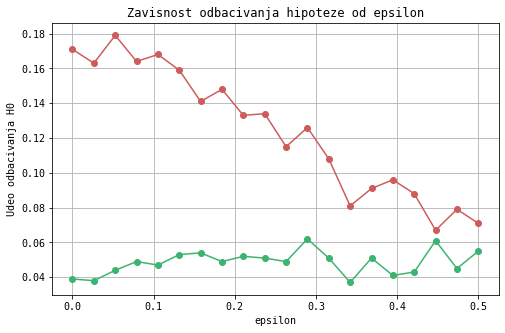

In [9]:
#Plorovanje
plt.figure(figsize=(8,5))
plt.plot(epsilons, udeo_odbacivanja1 , marker='o',color='mediumseagreen', label=r'$\mu$ = 0')
plt.plot(epsilons, udeo_odbacivanja2 , marker='o',color='indianred', label=r'$\mu$ = 0.5')
plt.xlabel("epsilon")
plt.ylabel("Udeo odbacivanja H0")
plt.title("Zavisnost odbacivanja hipoteze od epsilon")
plt.grid()
plt.show()

Kada je srednja vrednost pomerena udesno, odnosno normalna raspodela je pomerena udesno za 0.5 i kada je epsilon malo, član (1-epsilon) je približan jedinici, tako da se porede samo raspodele norm(0, 1) i norm(0.5,1) a one se razlikuju, tako da je stopa odbacivanja veća. To se vidi na crvenim tačkicama. Kako epsilon raste, smanjuje se značaj norm(0.5,1) i povećava se značaj normalne raspodele norm(0,3) koja se više poklapa sa prvobitnom, tako da stepen odbacivanja opada. 